In [6]:
import os
os.environ["PATH"] += ":/usr/local/gromacs/bin"

In [7]:
import sys
import matplotlib.pyplot as plt
import nglview as ng
import mdtraj as md
import pandas as pd

In [8]:
%cd ../data

/home/lorenzo/Desktop/GBI/Simulações/1FJS/data


In [ ]:
%rm -rf processing
%rm -rf figures
%rm -rf analysis
%mkdir processing
%mkdir figures
%mkdir analysis

In [10]:
view = ng.show_structure_file("input/1fjs.pdb")
view

NGLWidget()

In [11]:
!grep -v HETATM input/1fjs.pdb > processing/1fjs_protein_tmp.pdb
!grep -v CONECT processing/1fjs_protein_tmp.pdb > processing/1fjs_protein.pdb

In [12]:
!grep MISSING input/1fjs.pdb

In [13]:
%cd processing

/home/lorenzo/Desktop/GBI/Simulações/1FJS/data/processing


In [14]:
!gmx pdb2gmx \
    -f 1fjs_protein.pdb \
    -o 1fjs_processed.gro \
    -water tip3p \
    -ff charmm36

                     :-) GROMACS - gmx pdb2gmx, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /home/lorenzo/Desktop/GBI/Simulações/1FJS/data/processing
Command line:
  gmx pdb2gmx -f 1fjs_protein.pdb -o 1fjs_processed.gro -water tip3p -ff charmm36

Using the Charmm36 force field in directory charmm36.ff

going to rename charmm36.ff/aminoacids.r2b
Opening force field file /usr/local/gromacs/share/gromacs/top/charmm36.ff/aminoacids.r2b

going to rename charmm36.ff/carb.r2b
Opening force field file /usr/local/gromacs/share/gromacs/top/charmm36.ff/carb.r2b

going to rename charmm36.ff/cgenff.r2b
Opening force field file /usr/local/gromacs/share/gromacs/top/charmm36.ff/cgenff.r2b

going to rename charmm36.ff/ethers.r2b
Opening force field file /usr/local/gromacs/share/gromacs/top/charmm36.ff/ethers.r2b

going to rename charmm36.ff/lipid.r2b
Opening force field file /usr/local/gromacs/share/gromacs/top/charmm36.ff/lipid.r2b

going to rena

In [15]:
!cat ../steps/topol.top

cat: ../steps/topol.top: No such file or directory


In [16]:
!grep "moleculetype" -A 3 topol_Protein_chain_A.itp

[ moleculetype ]
; Name            nrexcl
Protein_chain_A     3



In [17]:
!grep "moleculetype" -A 3 topol_Protein_chain_L.itp

[ moleculetype ]
; Name            nrexcl
Protein_chain_L     3



In [18]:
! grep "atoms" -A 7 topol_Protein_chain_A.itp

[ atoms ]
;   nr       type  resnr residue  atom   cgnr     charge       mass  typeB    chargeB      massB
; residue  16 ILE rtp ILE  q +1.0
     1        NH3     16    ILE      N      1       -0.3     14.007
     2         HC     16    ILE     H1      2       0.33      1.008
     3         HC     16    ILE     H2      3       0.33      1.008
     4         HC     16    ILE     H3      4       0.33      1.008
     5        CT1     16    ILE     CA      5       0.21     12.011


In [19]:
!grep "bonds" -A 7 topol_Protein_chain_A.itp

[ bonds ]
;  ai    aj funct            c0            c1            c2            c3
    1     2     1 
    1     3     1 
    1     4     1 
    1     5     1 
    5     6     1 
    5     7     1 


In [20]:
!grep "angles" -A 7 topol_Protein_chain_A.itp

[ angles ]
;  ai    aj    ak funct            c0            c1            c2            c3
    2     1     3     5 
    2     1     4     5 
    2     1     5     5 
    3     1     4     5 
    3     1     5     5 
    4     1     5     5 


In [21]:
!grep "dihedrals" -A 7 topol_Protein_chain_A.itp

[ dihedrals ]
;  ai    aj    ak    al funct            c0            c1            c2            c3            c4            c5
    2     1     5     6     9 
    2     1     5     7     9 
    2     1     5    20     9 
    3     1     5     6     9 
    3     1     5     7     9 
    3     1     5    20     9 
--
[ dihedrals ]
;  ai    aj    ak    al funct            c0            c1            c2            c3
   20     5    22    21     2 
   22    20    24    23     2 
   36    24    38    37     2 
   38    36    40    39     2 
   43    40    45    44     2 
   45    43    47    46     2 


In [22]:
!grep "pairs" -A 7  topol_Protein_chain_A.itp

[ pairs ]
;  ai    aj funct            c0            c1            c2            c3
    1     8     1 
    1     9     1 
    1    13     1 
    1    21     1 
    1    22     1 
    2     6     1 


In [23]:
!grep "posre" -A 3 -B 3 topol_Protein_chain_A.itp


; Include Position restraint file
#ifdef POSRES
#include "posre_Protein_chain_A.itp"
#endif



In [24]:
!grep "position_restraints" -A 7 posre_Protein_chain_A.itp

[ position_restraints ]
; atom  type      fx      fy      fz
     1     1  1000  1000  1000
     5     1  1000  1000  1000
     7     1  1000  1000  1000
     9     1  1000  1000  1000
    13     1  1000  1000  1000
    16     1  1000  1000  1000


In [25]:
!grep "water topology" -A 8 topol.top

; Include water topology
#include "charmm36.ff/tip3p.itp"

#ifdef POSRES_WATER
; Position restraint for each water oxygen
[ position_restraints ]
;  i funct       fcx        fcy        fcz
   1    1       1000       1000       1000
#endif


In [26]:
!grep "ions" topol.top

; Include topology for ions
#include "charmm36.ff/ions.itp"


In [27]:
!grep "system" -A 7 topol.top

[ system ]
; Name
COAGULATION FACTOR XA; COAGULATION FACTOR XA

[ molecules ]
; Compound        #mols
Protein_chain_A     1
Protein_chain_L     1


In [28]:
!gmx editconf -f 1fjs_processed.gro -o 1fjs_newbox.gro -c -d 1.0 -bt cubic

                     :-) GROMACS - gmx editconf, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /home/lorenzo/Desktop/GBI/Simulações/1FJS/data/processing
Command line:
  gmx editconf -f 1fjs_processed.gro -o 1fjs_newbox.gro -c -d 1.0 -bt cubic

Note that major changes are planned in future for editconf, to improve usability and utility.
Read 4417 atoms
Volume: 321.98 nm^3, corresponds to roughly 144800 electrons
No velocities found
    system size :  6.066  5.213  4.092 (nm)
    diameter    :  6.268               (nm)
    center      :  2.234  1.342  2.544 (nm)
    box vectors :  5.577  7.196  8.023 (nm)
    box angles  :  90.00  90.00  90.00 (degrees)
    box volume  : 321.98               (nm^3)
    shift       :  1.900  2.791  1.590 (nm)
new center      :  4.134  4.134  4.134 (nm)
new box vectors :  8.268  8.268  8.268 (nm)
new box angles  :  90.00  90.00  90.00 (degrees)
new box volume  : 565.11               (nm^3)

GROMACS remi

In [29]:
!gmx solvate -cp 1fjs_newbox.gro -cs spc216.gro -o 1fjs_solv.gro -p topol.top

                     :-) GROMACS - gmx solvate, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /home/lorenzo/Desktop/GBI/Simulações/1FJS/data/processing
Command line:
  gmx solvate -cp 1fjs_newbox.gro -cs spc216.gro -o 1fjs_solv.gro -p topol.top

Reading solute configuration
Reading solvent configuration

Initialising inter-atomic distances...

         based on residue and atom names, since they could not be
         definitively assigned from the information in your input
         files. These guessed numbers might deviate from the mass
         and radius of the atom type. Please check the output
         files if necessary. Note, that this functionality may
         be removed in a future GROMACS version. Please, consider
         using another file format for your input.

         The atomic radii are set according to:

++++ PLEASE READ AND CITE THE FOLLOWING REFERENCE ++++
A. Bondi
van der Waals Volumes and Radii
J. Phys. Chem.

In [30]:
!tail topol.top


[ system ]
; Name
COAGULATION FACTOR XA; COAGULATION FACTOR XA in water

[ molecules ]
; Compound        #mols
Protein_chain_A     1
Protein_chain_L     1
SOL             17163


In [31]:
!touch viz.mdp
!gmx grompp -f viz.mdp -c 1fjs_solv.gro -p topol.top -o topol.tpr
!printf "0\n" | gmx trjconv -f 1fjs_solv.gro -s topol.tpr -o 1fjs_solv_viz.gro -pbc mol -ur compact

                      :-) GROMACS - gmx grompp, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /home/lorenzo/Desktop/GBI/Simulações/1FJS/data/processing
Command line:
  gmx grompp -f viz.mdp -c 1fjs_solv.gro -p topol.top -o topol.tpr


NOTE 1 [file viz.mdp]:
  For a correct single-point energy evaluation with nsteps = 0, use
  continuation = yes to avoid constraining the input coordinates.

Setting the LD random seed to -671092738

Generated 169542 of the 169653 non-bonded parameter combinations
Generating 1-4 interactions: fudge = 1

Generated 118878 of the 169653 1-4 parameter combinations

Excluding 3 bonded neighbours molecule type 'Protein_chain_A'

Excluding 3 bonded neighbours molecule type 'Protein_chain_L'

Excluding 2 bonded neighbours molecule type 'SOL'

NOTE 2 [file topol.top, line 48]:
  System has non-zero total charge: -2.000000
  Total charge should normally be an integer. See
  https://manual.gromacs.org/current/use

In [32]:
!grep "bonds" -B 20 topol_Protein_chain_A.itp

  3656         HC    243    LYS    HZ3   3656       0.33      1.008
  3657          C    243    LYS      C   3657       0.51     12.011
  3658          O    243    LYS      O   3658      -0.51    15.9994   ; qtot 2
; residue 244 THR rtp THR  q -1.0
  3659        NH1    244    THR      N   3659      -0.47     14.007
  3660          H    244    THR     HN   3660       0.31      1.008
  3661        CT1    244    THR     CA   3661       0.07     12.011
  3662        HB1    244    THR     HA   3662       0.09      1.008
  3663        CT1    244    THR     CB   3663       0.14     12.011
  3664        HA1    244    THR     HB   3664       0.09      1.008
  3665        OH1    244    THR    OG1   3665      -0.66    15.9994
  3666          H    244    THR    HG1   3666       0.43      1.008
  3667        CT3    244    THR    CG2   3667      -0.27     12.011
  3668        HA3    244    THR   HG21   3668       0.09      1.008
  3669        HA3    244    THR   HG22   3669       0.09      1.008
  3

In [33]:
!grep "bonds" -B 20 topol_Protein_chain_L.itp

   727          C    137    LEU      C    727       0.51     12.011
   728          O    137    LEU      O    728      -0.51    15.9994   ; qtot -1
; residue 138 GLU rtp GLU  q -2.0
   729        NH1    138    GLU      N    729      -0.47     14.007
   730          H    138    GLU     HN    730       0.31      1.008
   731        CT1    138    GLU     CA    731       0.07     12.011
   732        HB1    138    GLU     HA    732       0.09      1.008
   733       CT2A    138    GLU     CB    733      -0.18     12.011
   734        HA2    138    GLU    HB1    734       0.09      1.008
   735        HA2    138    GLU    HB2    735       0.09      1.008
   736        CT2    138    GLU     CG    736      -0.28     12.011
   737        HA2    138    GLU    HG1    737       0.09      1.008
   738        HA2    138    GLU    HG2    738       0.09      1.008
   739         CC    138    GLU     CD    739       0.62     12.011
   740         OC    138    GLU    OE1    740      -0.76    15.9994
  

In [34]:
!touch ions.mdp

In [35]:
!gmx grompp -f ions.mdp -c 1fjs_solv.gro -p topol.top -o ions.tpr

                      :-) GROMACS - gmx grompp, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /home/lorenzo/Desktop/GBI/Simulações/1FJS/data/processing
Command line:
  gmx grompp -f ions.mdp -c 1fjs_solv.gro -p topol.top -o ions.tpr


NOTE 1 [file ions.mdp]:
  For a correct single-point energy evaluation with nsteps = 0, use
  continuation = yes to avoid constraining the input coordinates.

Setting the LD random seed to 1476394943

Generated 169542 of the 169653 non-bonded parameter combinations
Generating 1-4 interactions: fudge = 1

Generated 118878 of the 169653 1-4 parameter combinations

Excluding 3 bonded neighbours molecule type 'Protein_chain_A'

Excluding 3 bonded neighbours molecule type 'Protein_chain_L'

Excluding 2 bonded neighbours molecule type 'SOL'

NOTE 2 [file topol.top, line 48]:
  System has non-zero total charge: -2.000000
  Total charge should normally be an integer. See
  https://manual.gromacs.org/current/us

In [36]:
!printf "SOL\n" | gmx genion -s ions.tpr -o 1fjs_solv_ions.gro -conc 0.15 -p \
topol.top -pname NA -nname CL -neutral

                      :-) GROMACS - gmx genion, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /home/lorenzo/Desktop/GBI/Simulações/1FJS/data/processing
Command line:
  gmx genion -s ions.tpr -o 1fjs_solv_ions.gro -conc 0.15 -p topol.top -pname NA -nname CL -neutral

Reading file ions.tpr, VERSION 2026.3 (single precision)
Reading file ions.tpr, VERSION 2026.3 (single precision)
Will try to add 53 NA ions and 51 CL ions.
Select a continuous group of solvent molecules
Group     0 (         System) has 55906 elements
Group     1 (        Protein) has  4417 elements
Group     2 (      Protein-H) has  2238 elements
Group     3 (        C-alpha) has   286 elements
Group     4 (       Backbone) has   858 elements
Group     5 (      MainChain) has  1142 elements
Group     6 (   MainChain+Cb) has  1401 elements
Group     7 (    MainChain+H) has  1423 elements
Group     8 (      SideChain) has  2994 elements
Group     9 (    SideChain-H) has 

In [37]:
!gmx grompp -f viz.mdp -c 1fjs_solv_ions.gro -p topol.top -o topol.tpr
!printf "0\n" | gmx trjconv -f 1fjs_solv_ions.gro -s topol.tpr -o 1fjs_solv_ions_viz.gro -pbc mol -ur compact

                      :-) GROMACS - gmx grompp, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /home/lorenzo/Desktop/GBI/Simulações/1FJS/data/processing
Command line:
  gmx grompp -f viz.mdp -c 1fjs_solv_ions.gro -p topol.top -o topol.tpr


NOTE 1 [file viz.mdp]:
  For a correct single-point energy evaluation with nsteps = 0, use
  continuation = yes to avoid constraining the input coordinates.

Setting the LD random seed to -103809569

Generated 169542 of the 169653 non-bonded parameter combinations
Generating 1-4 interactions: fudge = 1

Generated 118878 of the 169653 1-4 parameter combinations

Excluding 3 bonded neighbours molecule type 'Protein_chain_A'

Excluding 3 bonded neighbours molecule type 'Protein_chain_L'

Excluding 2 bonded neighbours molecule type 'SOL'

Excluding 3 bonded neighbours molecule type 'NA'

Excluding 3 bonded neighbours molecule type 'CL'

Taking velocities from '1fjs_solv_ions.gro', all velocities are z

In [38]:
!cat ../input/emin-charmm.mdp

title       = CHARMM steepest descent enrgy minimisation

; Parameters describing what to do, when to stop and what to save
integrator  = steep  ; Algorithm (steep = steepest descent minimization)
emtol       = 1000.0 ; Stop minimization when the maximum force < 1000.0 kJ/mol/nm
emstep      = 0.01   ; Minimization step size
nstenergy   = 500    ; save energies every 1.0 ps, so we can observe if we are successful
nsteps      = -1     ; run as long as we need
; Settings that make sure we run with parameters in harmony with the selected force-field
constraints             = h-bonds   ; bonds involving H are constrained
rcoulomb                = 1.2       ; short-range electrostatic cutoff (in nm)
rvdw                    = 1.2       ; short-range van der Waals cutoff (in nm)
vdw-modifier            = Force-switch ;  specific CHARMM
rvdw_switch             = 1.0       ;
DispCorr                = no        ; account for cut-off vdW scheme -
;in case of CHARMM DispCorr = EnerPres only for mon

In [39]:
!gmx grompp -f ../input/emin-charmm.mdp -c 1fjs_solv_ions.gro -p topol.top -o em.tpr

                      :-) GROMACS - gmx grompp, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /home/lorenzo/Desktop/GBI/Simulações/1FJS/data/processing
Command line:
  gmx grompp -f ../input/emin-charmm.mdp -c 1fjs_solv_ions.gro -p topol.top -o em.tpr

Ignoring obsolete mdp entry 'title'
Setting the LD random seed to -404623373

Generated 169542 of the 169653 non-bonded parameter combinations
Generating 1-4 interactions: fudge = 1

Generated 118878 of the 169653 1-4 parameter combinations

Excluding 3 bonded neighbours molecule type 'Protein_chain_A'

turning H bonds into constraints...

Excluding 3 bonded neighbours molecule type 'Protein_chain_L'

turning H bonds into constraints...

Excluding 2 bonded neighbours molecule type 'SOL'

turning H bonds into constraints...

Excluding 3 bonded neighbours molecule type 'NA'

turning H bonds into constraints...

Excluding 3 bonded neighbours molecule type 'CL'

turning H bonds into const

In [40]:
!gmx mdrun -v -deffnm em -ntmpi 1 -ntomp 1

                      :-) GROMACS - gmx mdrun, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /home/lorenzo/Desktop/GBI/Simulações/1FJS/data/processing
Command line:
  gmx mdrun -v -deffnm em -ntmpi 1 -ntomp 1

Reading file em.tpr, VERSION 2026.3 (single precision)
1 GPU selected for this run.
Mapping of GPU IDs to the 1 GPU task in the 1 rank on this node:
  PP:0
PP tasks will do non-perturbed short-ranged interactions on the GPU
PP task will update and constrain coordinates on the CPU
Using 1 MPI thread
Using 1 OpenMP thread 


NOTE: Thread affinity was not set.

Steepest Descents:
   Tolerance (Fmax)   =  1.00000e+03
   Number of steps    =           -1
Step=    0, Dmax= 1.0e-02 nm, Epot= -2.19277e+05 Fmax= 4.52055e+05, atom= 2834
Step=    1, Dmax= 1.0e-02 nm, Epot= -2.87074e+05 Fmax= 1.20571e+05, atom= 2532
Step=    2, Dmax= 1.2e-02 nm, Epot= -4.07368e+05 Fmax= 4.52961e+04, atom= 33389
Step=    3, Dmax= 1.4e-02 nm, Epot= -4.99722

In [41]:
!printf "Potential\n0\n" | gmx energy -f em.edr -o ../analysis/potential.xvg -xvg none

                      :-) GROMACS - gmx energy, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /home/lorenzo/Desktop/GBI/Simulações/1FJS/data/processing
Command line:
  gmx energy -f em.edr -o ../analysis/potential.xvg -xvg none

Opened em.edr as single precision energy file

Select the terms you want from the following list by
selecting either (part of) the name or the number or a combination.
End your selection with an empty line or a zero.
-------------------------------------------------------------------
  1  Bond             2  U-B              3  Proper-Dih.      4  Improper-Dih. 
  5  CMAP-Dih.        6  LJ-14            7  Coulomb-14       8  LJ-(SR)       
  9  Coulomb-(SR)    10  Coul.-recip.    11  Potential       12  Pressure      
 13  Constr.-rmsd    14  Vir-XX          15  Vir-XY          16  Vir-XZ        
 17  Vir-YX          18  Vir-YY          19  Vir-YZ          20  Vir-ZX        
 21  Vir-ZY          22  Vir-ZZ 

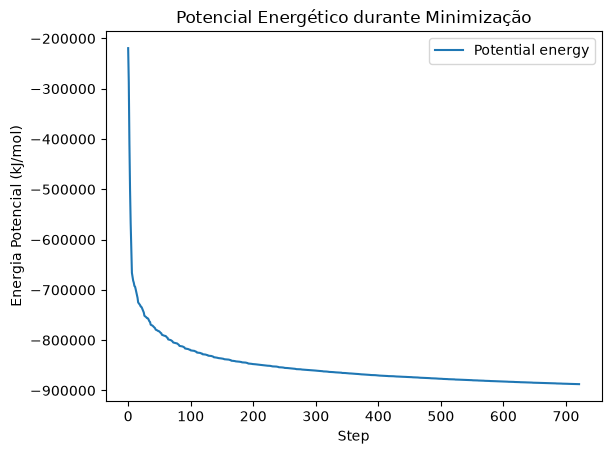

In [42]:
df = pd.read_csv('../analysis/potential.xvg', sep='\\s+', header=None, names=['Potential energy'])
ax = df.plot(xlabel = 'Step', ylabel = 'Energia Potencial (kJ/mol)', title = "Potencial Energético durante Minimização")
fig = ax.get_figure()
fig.savefig('../figures/Potential_Energy.png', dpi=300, bbox_inches='tight')
plt.show()

In [43]:
!gmx grompp -f ../input/nvt-charmm.mdp -c em.gro -r em.gro -p topol.top -o nvt.tpr 
!gmx mdrun -ntmpi 1 -ntomp 8 -v -deffnm nvt

                      :-) GROMACS - gmx grompp, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /home/lorenzo/Desktop/GBI/Simulações/1FJS/data/processing
Command line:
  gmx grompp -f ../input/nvt-charmm.mdp -c em.gro -r em.gro -p topol.top -o nvt.tpr

Ignoring obsolete mdp entry 'title'
Setting the LD random seed to 2078261246

Generated 169542 of the 169653 non-bonded parameter combinations
Generating 1-4 interactions: fudge = 1

Generated 118878 of the 169653 1-4 parameter combinations

Excluding 3 bonded neighbours molecule type 'Protein_chain_A'

turning H bonds into constraints...

Excluding 3 bonded neighbours molecule type 'Protein_chain_L'

turning H bonds into constraints...

Excluding 2 bonded neighbours molecule type 'SOL'

turning H bonds into constraints...

Excluding 3 bonded neighbours molecule type 'NA'

turning H bonds into constraints...

Excluding 3 bonded neighbours molecule type 'CL'

turning H bonds into constra

In [44]:
!echo "Temperature" | gmx energy -f nvt.edr -o ../analysis/temperature.xvg -xvg none -b 20

                      :-) GROMACS - gmx energy, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /home/lorenzo/Desktop/GBI/Simulações/1FJS/data/processing
Command line:
  gmx energy -f nvt.edr -o ../analysis/temperature.xvg -xvg none -b 20

Opened nvt.edr as single precision energy file

Select the terms you want from the following list by
selecting either (part of) the name or the number or a combination.
End your selection with an empty line or a zero.
-------------------------------------------------------------------
  1  Bond             2  U-B              3  Proper-Dih.      4  Improper-Dih. 
  5  CMAP-Dih.        6  LJ-14            7  Coulomb-14       8  LJ-(SR)       
  9  Coulomb-(SR)    10  Coul.-recip.    11  Position-Rest.  12  Potential     
 13  Kinetic-En.     14  Total-Energy    15  Conserved-En.   16  Temperature   
 17  Pressure        18  Constr.-rmsd    19  Vir-XX          20  Vir-XY        
 21  Vir-XZ          2

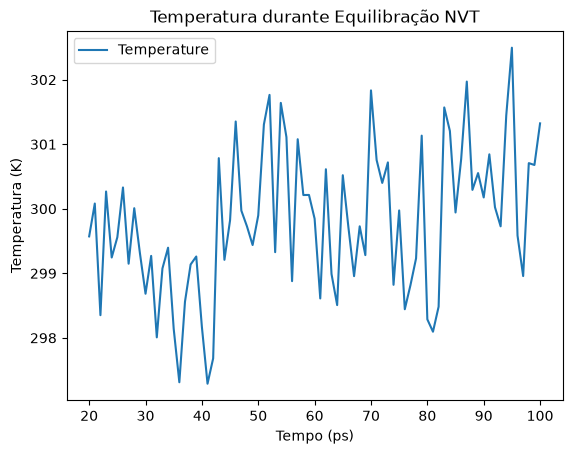

In [45]:
df = pd.read_csv('../analysis/temperature.xvg', sep='\\s+', header=None, names=['Temperature'])
ax = df.plot(xlabel = 'Tempo (ps)', ylabel = 'Temperatura (K)', title = "Temperatura durante Equilibração NVT")
fig = ax.get_figure()
fig.savefig('../figures/Temperature_Energy.png', dpi=300, bbox_inches='tight')
plt.show()

In [46]:
!gmx grompp -f ../input/npt-charmm.mdp -c nvt.gro -r nvt.gro -t nvt.cpt -p topol.top -o npt.tpr

                      :-) GROMACS - gmx grompp, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /home/lorenzo/Desktop/GBI/Simulações/1FJS/data/processing
Command line:
  gmx grompp -f ../input/npt-charmm.mdp -c nvt.gro -r nvt.gro -t nvt.cpt -p topol.top -o npt.tpr

Ignoring obsolete mdp entry 'title'
Setting the LD random seed to -1682440449

Generated 169542 of the 169653 non-bonded parameter combinations
Generating 1-4 interactions: fudge = 1

Generated 118878 of the 169653 1-4 parameter combinations

Excluding 3 bonded neighbours molecule type 'Protein_chain_A'

turning H bonds into constraints...

Excluding 3 bonded neighbours molecule type 'Protein_chain_L'

turning H bonds into constraints...

Excluding 2 bonded neighbours molecule type 'SOL'

turning H bonds into constraints...

Excluding 3 bonded neighbours molecule type 'NA'

turning H bonds into constraints...

Excluding 3 bonded neighbours molecule type 'CL'

turning H bond

In [47]:
!gmx mdrun -ntmpi 1 -ntomp 8 -v -deffnm npt

                      :-) GROMACS - gmx mdrun, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /home/lorenzo/Desktop/GBI/Simulações/1FJS/data/processing
Command line:
  gmx mdrun -ntmpi 1 -ntomp 8 -v -deffnm npt

Reading file npt.tpr, VERSION 2026.3 (single precision)
Changing nstlist from 10 to 100, rlist from 1.2 to 1.356

1 GPU selected for this run.
Mapping of GPU IDs to the 2 GPU tasks in the 1 rank on this node:
  PP:0,PME:0
PP tasks will do non-perturbed short-ranged interactions on the GPU
PP task will update and constrain coordinates on the GPU
PME tasks will do all aspects on the GPU
Using 1 MPI thread
Using 8 OpenMP threads 


NOTE: The number of threads is not equal to the number of (logical) cpus
      and the -pin option is set to auto: will not pin threads to cpus.
      This can lead to significant performance degradation.
      Consider using -pin on (and -pinoffset in case you run multiple jobs).
starting mdrun 'COAG

In [48]:
!echo "Pressure" | gmx energy -f npt.edr -o ../analysis/pressure.xvg -xvg none

                      :-) GROMACS - gmx energy, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /home/lorenzo/Desktop/GBI/Simulações/1FJS/data/processing
Command line:
  gmx energy -f npt.edr -o ../analysis/pressure.xvg -xvg none

Opened npt.edr as single precision energy file

Select the terms you want from the following list by
selecting either (part of) the name or the number or a combination.
End your selection with an empty line or a zero.
-------------------------------------------------------------------
  1  Bond             2  U-B              3  Proper-Dih.      4  Improper-Dih. 
  5  CMAP-Dih.        6  LJ-14            7  Coulomb-14       8  LJ-(SR)       
  9  Coulomb-(SR)    10  Coul.-recip.    11  Position-Rest.  12  Potential     
 13  Kinetic-En.     14  Total-Energy    15  Conserved-En.   16  Temperature   
 17  Pressure        18  Constr.-rmsd    19  Box-X           20  Box-Y         
 21  Box-Z           22  Volume

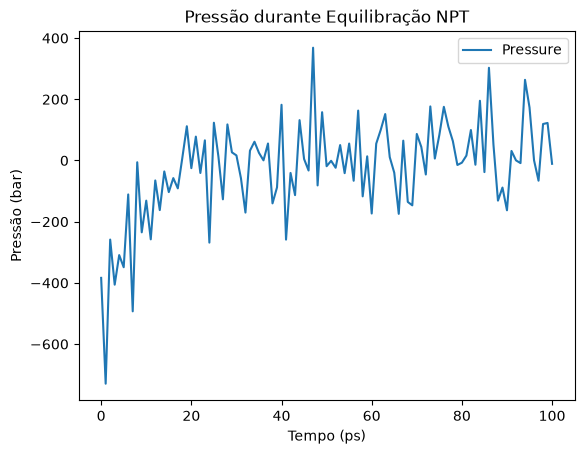

In [49]:
df = pd.read_csv('../analysis/pressure.xvg', sep='\\s+', header=None, names=['Pressure'])
ax = df.plot(xlabel = 'Tempo (ps)', ylabel = 'Pressão (bar)', title = "Pressão durante Equilibração NPT")
fig = ax.get_figure()
fig.savefig('../figures/Pressure_Energy.png', dpi=300, bbox_inches='tight')
plt.show()

In [50]:
!echo "Density" | gmx energy -f npt.edr -o ../analysis/density.xvg -xvg none

                      :-) GROMACS - gmx energy, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /home/lorenzo/Desktop/GBI/Simulações/1FJS/data/processing
Command line:
  gmx energy -f npt.edr -o ../analysis/density.xvg -xvg none

Opened npt.edr as single precision energy file

Select the terms you want from the following list by
selecting either (part of) the name or the number or a combination.
End your selection with an empty line or a zero.
-------------------------------------------------------------------
  1  Bond             2  U-B              3  Proper-Dih.      4  Improper-Dih. 
  5  CMAP-Dih.        6  LJ-14            7  Coulomb-14       8  LJ-(SR)       
  9  Coulomb-(SR)    10  Coul.-recip.    11  Position-Rest.  12  Potential     
 13  Kinetic-En.     14  Total-Energy    15  Conserved-En.   16  Temperature   
 17  Pressure        18  Constr.-rmsd    19  Box-X           20  Box-Y         
 21  Box-Z           22  Volume 

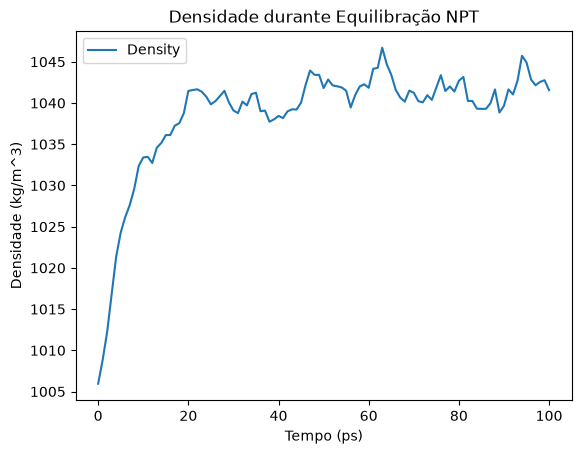

In [51]:
df = pd.read_csv('../analysis/density.xvg', sep='\\s+', header=None, names=['Density'])
ax = df.plot(xlabel = 'Tempo (ps)', ylabel = 'Densidade (kg/m^3)', title = "Densidade durante Equilibração NPT")
fig = ax.get_figure()
fig.savefig('../figures/Density_Energy.png', dpi=300, bbox_inches='tight')
plt.show()

In [52]:
!gmx grompp -f ../input/md-charmm.mdp -c npt.gro -t npt.cpt -p topol.top -o md.tpr

                      :-) GROMACS - gmx grompp, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /home/lorenzo/Desktop/GBI/Simulações/1FJS/data/processing
Command line:
  gmx grompp -f ../input/md-charmm.mdp -c npt.gro -t npt.cpt -p topol.top -o md.tpr

Ignoring obsolete mdp entry 'title'
Setting the LD random seed to -1125143425

Generated 169542 of the 169653 non-bonded parameter combinations
Generating 1-4 interactions: fudge = 1

Generated 118878 of the 169653 1-4 parameter combinations

Excluding 3 bonded neighbours molecule type 'Protein_chain_A'

turning H bonds into constraints...

Excluding 3 bonded neighbours molecule type 'Protein_chain_L'

turning H bonds into constraints...

Excluding 2 bonded neighbours molecule type 'SOL'

turning H bonds into constraints...

Excluding 3 bonded neighbours molecule type 'NA'

turning H bonds into constraints...

Excluding 3 bonded neighbours molecule type 'CL'

turning H bonds into constr

In [ ]:
!gmx mdrun -ntmpi 1 -ntomp 8 -v -deffnm md 

                      :-) GROMACS - gmx mdrun, 2026.3 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /home/lorenzo/Desktop/GBI/Simulações/1FJS/data/processing
Command line:
  gmx mdrun -ntmpi 1 -ntomp 8 -v -deffnm md

Reading file md.tpr, VERSION 2026.3 (single precision)
Changing nstlist from 10 to 100, rlist from 1.2 to 1.359

1 GPU selected for this run.
Mapping of GPU IDs to the 2 GPU tasks in the 1 rank on this node:
  PP:0,PME:0
PP tasks will do non-perturbed short-ranged interactions on the GPU
PP task will update and constrain coordinates on the GPU
PME tasks will do all aspects on the GPU
Using 1 MPI thread
Using 8 OpenMP threads 


NOTE: The number of threads is not equal to the number of (logical) cpus
      and the -pin option is set to auto: will not pin threads to cpus.
      This can lead to significant performance degradation.
      Consider using -pin on (and -pinoffset in case you run multiple jobs).
starting mdrun 'COAGUL

In [ ]:
!gmx trjconv -h

In [ ]:
!printf "1" | gmx trjconv -s md.tpr -f md.xtc -o md_whole.xtc -pbc whole
!printf "1" | gmx trjconv -s md.tpr -f md_whole.xtc -o md_nojump.xtc -pbc nojump
!printf "1\n1" | gmx trjconv -s md.tpr -f md_nojump.xtc -o md_mol.xtc -center -pbc mol

In [ ]:
!printf "1\n" | gmx mindist -s md.tpr -f md_mol.xtc -pi -od ../analysis/mindist.xvg 


In [ ]:
!printf "4\n1\n" | gmx rms -s em.tpr -f md_mol.xtc -o ../analysis/rmsd_xray.xvg -tu ns -xvg none

In [ ]:
df = pd.read_csv('../analysis/rmsd_xray.xvg', sep='\\s+', header=None, names=['RMSD'])
ax = df.plot(xlabel = 'Tempo (ns)', ylabel = 'RMSD (nm)', title = "Root Mean Square Deviation (RMSD) da Proteína em Produção")
fig = ax.get_figure()
fig.savefig('../figures/RMSD_xray.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
!echo "1" | gmx gyrate -f md_mol.xtc -s md.tpr -o ../analysis/gyrate.xvg -xvg none

In [ ]:
df = pd.read_csv('../analysis/gyrate.xvg', sep='\\s+', header=None, names=['Rg'], usecols=[1])
ax = df.plot(xlabel = 'Tempo (ps)', ylabel = 'Raio de Giração (nm)', title = "Raio de Giração (Rg) da Proteína em Produção")
fig = ax.get_figure()
fig.savefig('../figures/Gyrate_rg.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
!printf "1\n" | gmx rmsf -s md.tpr -f md_mol.xtc -o ../analysis/rmsf.xvg -res -xvg none

In [ ]:
df = pd.read_csv('../analysis/rmsf.xvg', sep='\\s+', header=None, names=['RMSF'])
ax = df.plot(xlabel = 'Resíduo', ylabel = 'RMSF (nm)', title = "Root Mean Square Fluctuation (RMSF) da Proteína em Produção")
fig = ax.get_figure()
fig.savefig('../figures/RMSF.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
!gmx sasa -s md.tpr -f md_mol.xtc -o ../analysis/sasa.xvg -surface 'group "Protein"' -output 'group "Protein"' -tu ns -xvg none

In [ ]:
df = pd.read_csv('../analysis/sasa.xvg', sep='\\s+', header=None, names=['SASA'])
ax = df.plot(xlabel = 'Tempo (ns)', ylabel = 'SASA (nm²)', title = "Área de Superfície Acessível ao Solvente (SASA) da Proteína em Produção")
fig = ax.get_figure()
fig.savefig('../figures/SASA.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
traj = md.load('md_mol.xtc', top='md.gro')
protein = traj.atom_slice(traj.topology.select('protein'))
dssp = md.compute_dssp(protein, simplified=True)
pd.DataFrame({'Tempo': traj.time / 1000, 'Alpha Helix': (dssp == 'H').mean(axis=1)}).to_csv('../analysis/alpha_helix.xvg', sep=' ', header=False, index=False)
pd.DataFrame({'Tempo': traj.time / 1000, 'Beta Sheet': (dssp == 'E').mean(axis=1)}).to_csv('../analysis/beta_sheet.xvg', sep=' ', header=False, index=False)
pd.DataFrame({'Tempo': traj.time / 1000, 'Coils': (dssp == 'C').mean(axis=1)}).to_csv('../analysis/coils.xvg', sep=' ', header=False, index=False)

In [ ]:
df = pd.read_csv('../analysis/alpha_helix.xvg', sep='\\s+', header=None, names=['Alpha Helix'])
ax = df.plot(xlabel = 'Tempo (ns)', ylabel = 'Fração de Resíduos', title = "Fração de Hélice Alfa da Proteína em Produção")
fig = ax.get_figure()
fig.savefig('../figures/Alpha_Helix.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
df = pd.read_csv('../analysis/beta_sheet.xvg', sep='\\s+', header=None, names=['Beta Sheet'])
ax = df.plot(xlabel = 'Tempo (ns)', ylabel = 'Fração de Resíduos', title = "Fração de Folha Beta da Proteína em Produção")
fig = ax.get_figure()
fig.savefig('../figures/Beta_Sheet.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
df = pd.read_csv('../analysis/coils.xvg', sep='\\s+', header=None, names=['Coils'])
ax = df.plot(xlabel = 'Tempo (ns)', ylabel = 'Fração de Resíduos', title = "Fração de Coils da Proteína em Produção")
fig = ax.get_figure()
fig.savefig('../figures/Coils.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
!printf "h\nq\n" | gmx make_ndx -f nvt.tpr -o

In [ ]:
!printf "splitch 1\nq\n" | gmx make_ndx -f nvt.tpr -o chains_make_ndx.ndx

In [ ]:
!printf "group "Protein" and mol 1\ngroup "Protein" and mol 2" | gmx select -s nvt.tpr -on chains_select.ndx

In [ ]:
!printf "17\n18\n"| gmx hbond -f md.xtc -s md.tpr -n chains_make_ndx.ndx -num ../analysis/hbnum_ndx.xvg -xvg none

In [ ]:
!printf "0\n1\n"| gmx hbond -f md.xtc -s md.tpr -n chains_select.ndx -num ../analysis/hbnum.xvg -xvg none

In [ ]:
df = pd.read_csv('../analysis/hbnum_ndx.xvg', sep='\\s+', header=None, names=['H-bonds'])
ax = df.plot(xlabel = 'Tempo (ps)', ylabel = 'Ligações de Hidrogênio', title = "Número de Ligações de Hidrogênio entre Cadeias")
fig = ax.get_figure()
fig.savefig('../figures/hbonds.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
!gmx report-methods -s md.tpr